# EDS Price Panel EDA

This notebook is an interpreted EDA pass over the current real EDS price panel artifact.

The notebook separates the two modes of work:

- ordinary code/table/plot cells are the legwork;
- red interpretation cells are the data-quality and modeling-readiness reading of those results.

Current local artifacts:

```text
data/model_ready/price_panel_hourly_v1.parquet
data/model_ready/price_panel_hourly_v1_eda.parquet
```

Both currently come from the focused real-data EDA raw slice. They cover Danish local delivery time from 2024-01-01 through 2026-07-01 and include the 2025-10-01 EDS source transition. This is not yet the eventual full-history backfill.


<span style="color:#b00020"><strong>Interpretation.</strong> The local canonical <code>v1</code> file is now available for modeling notebooks, but it was built from the focused <code>energi_data_service_eda</code> raw slice because the full EDS backfill hit API throttling. That is good enough for early model development and source-transition/DST checks; it should not be mistaken for the final full-history training artifact.</span>


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not find project root with pyproject.toml and src/")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from dkenergy_forecast.io import load_price_panel

PANEL_CANDIDATES = [
    PROJECT_ROOT / "data" / "model_ready" / "price_panel_hourly_v1.parquet",
    PROJECT_ROOT / "data" / "model_ready" / "price_panel_hourly_v1_eda.parquet",
]

PANEL_PATH = next((path for path in PANEL_CANDIDATES if path.exists()), PANEL_CANDIDATES[0])
QA_PATH = PANEL_PATH.with_name(PANEL_PATH.stem + ".qa.json")
DATA_READY = PANEL_PATH.exists()

print(f"Project root: {PROJECT_ROOT}")
print(f"Panel path: {PANEL_PATH}")
print(f"QA path: {QA_PATH}")


Project root: /Users/peterbjerrehansen/Desktop/projects/coding_projects/on_github/dk_energy_forecasts
Panel path: /Users/peterbjerrehansen/Desktop/projects/coding_projects/on_github/dk_energy_forecasts/data/model_ready/price_panel_hourly_v1.parquet
QA path: /Users/peterbjerrehansen/Desktop/projects/coding_projects/on_github/dk_energy_forecasts/data/model_ready/price_panel_hourly_v1.qa.json


In [2]:
if not DATA_READY:
    panel = pd.DataFrame()
    qa = {}
    display(
        Markdown(
            "**No model-ready panel found.** Run either the full build or the focused EDA build first.\n\n"
            "Full intended build:\n"
            "```bash\n"
            "python scripts/fetch_eds_prices.py --areas DK1 DK2\n"
            "python scripts/build_price_panel.py --dataset-version v1\n"
            "```\n\n"
            "Focused EDA build used for this notebook:\n"
            "```bash\n"
            "python scripts/build_price_panel.py --raw-dir data/raw/energi_data_service_eda --start 2024-01-01 --end 2026-07-02 --dataset-version v1_eda\n"
            "```"
        )
    )
else:
    panel = load_price_panel(PANEL_PATH, QA_PATH if QA_PATH.exists() else None, require_final_historical=False).copy()
    qa = json.loads(QA_PATH.read_text(encoding="utf-8")) if QA_PATH.exists() else {}
    panel["local_month_period"] = panel["ds_local"].dt.strftime("%Y-%m")
    panel["local_year"] = panel["ds_local"].dt.year
    display(Markdown(f"Loaded **{len(panel):,}** rows from `{PANEL_PATH.relative_to(PROJECT_ROOT)}`."))


Loaded **274,750** rows from `data/model_ready/price_panel_hourly_v1.parquet`.

## 1. QA And Scope

Start with the QA artifact. It tells us whether the panel is internally coherent before we look for market patterns.


In [3]:
if DATA_READY:
    qa_rows = [
        ("dataset_version", qa.get("dataset_version")),
        ("artifact_status", qa.get("artifact_status")),
        ("row_count", qa.get("row_count")),
        ("utc_range", f"{qa.get('min_ds_utc')} -> {qa.get('max_ds_utc')}"),
        ("areas", qa.get("areas")),
        ("duplicate_key_count", qa.get("duplicate_key_count")),
        ("missing_hour_count", qa.get("missing_hour_count")),
        ("negative_price_count", qa.get("negative_price_count")),
        ("transition_boundary_check", qa.get("transition_boundary_check", {}).get("status")),
        ("shared_utc_coverage_check", qa.get("shared_utc_coverage_check", {}).get("status")),
    ]
    display(pd.DataFrame(qa_rows, columns=["field", "value"]))


,field,value
0,dataset_version,v1
1,artifact_status,final_historical
2,row_count,274750
3,utc_range,2010-10-31T23:00:00+00:00 -> 2026-07-03T21:00:...
4,areas,"[DK1, DK2]"
5,duplicate_key_count,0
6,missing_hour_count,0
7,negative_price_count,3424
8,transition_boundary_check,pass
9,shared_utc_coverage_check,pass


<span style="color:#b00020"><strong>Interpretation.</strong> The focused EDA panel passes the structural checks that matter for early forecasting: 43,822 rows, exactly 21,911 per area, no missing UTC hours, no duplicate forecast keys, and shared DK1/DK2 UTC coverage. The source transition check passes. There are 1,566 negative-price area-hours, which is a market feature, not a cleaning error.</span>


## 2. Source Coverage

This panel deliberately spans both EDS price schemas.


In [4]:
if DATA_READY:
    source_summary = (
        panel.groupby(["source_dataset", "area"])
        .agg(
            rows=("y", "size"),
            min_local=("ds_local", "min"),
            max_local=("ds_local", "max"),
            median_price=("y", "median"),
        )
        .reset_index()
    )
    display(source_summary)


,source_dataset,area,rows,min_local,max_local,median_price
0,DayAheadPrices,DK1,6624,2025-10-01 00:00:00+02:00,2026-07-03 23:00:00+02:00,704.820593
1,DayAheadPrices,DK2,6624,2025-10-01 00:00:00+02:00,2026-07-03 23:00:00+02:00,719.110447
2,Elspotprices,DK1,130751,2010-11-01 00:00:00+01:00,2025-09-30 23:00:00+02:00,289.660004
3,Elspotprices,DK2,130751,2010-11-01 00:00:00+01:00,2025-09-30 23:00:00+02:00,296.660004


<span style="color:#b00020"><strong>Interpretation.</strong> The old source contributes 15,335 hourly rows per area from 2024-01-01 through 2025-09-30. The new source contributes 6,576 hourly rows per area from 2025-10-01 through 2026-07-01 after quarter-hour aggregation. The higher median in the new-source period is not automatically a source artifact; it also reflects the later market period. We should not train a model feature on <code>source_dataset</code> for v1, but we should keep it as audit metadata.</span>


## 3. Price Distribution And Negative Prices

Negative prices are valid. The EDA question is how frequent and extreme they are, not whether to remove them.


In [5]:
if DATA_READY:
    price_summary = panel.groupby("area")["y"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(2)
    negative_by_area = (
        panel.assign(is_negative=panel["y"] < 0)
        .groupby("area")["is_negative"]
        .agg(negative_hours="sum", negative_share="mean")
    )
    negative_by_area["negative_share"] = negative_by_area["negative_share"].round(4)
    display(price_summary)
    display(negative_by_area)


,count,mean,std,min,1%,5%,50%,95%,99%,max
area,,,,,,,,,,
DK1,137375.0,449.53,509.79,-3277.39,-6.7,55.52,297.65,1268.96,2826.05,14910.8
DK2,137375.0,453.91,502.42,-1491.92,0.0,70.20,303.47,1286.19,2799.24,14903.6


,negative_hours,negative_share
area,,
DK1,2085,0.0152
DK2,1339,0.0097


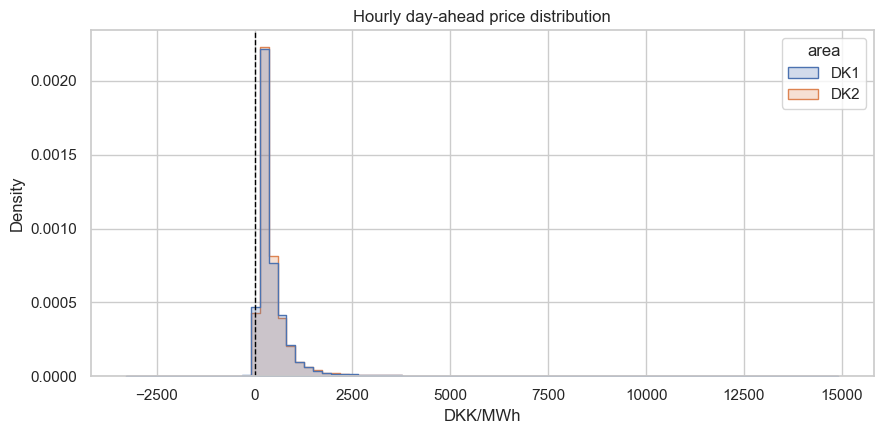

In [6]:
if DATA_READY:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    if sns is not None:
        sns.histplot(
            data=panel,
            x="y",
            hue="area",
            bins=80,
            element="step",
            stat="density",
            common_norm=False,
            ax=ax,
        )
    else:
        for area, frame in panel.groupby("area"):
            ax.hist(frame["y"], bins=80, density=True, alpha=0.45, label=area)
        ax.legend()
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title("Hourly day-ahead price distribution")
    ax.set_xlabel("DKK/MWh")
    ax.set_ylabel("Density")
    fig.tight_layout()
    plt.show()


<span style="color:#b00020"><strong>Interpretation.</strong> DK1 and DK2 have similar medians, around 620 DKK/MWh, but the tails are large. The maximum is about 6,983 DKK/MWh on 2024-12-12, and the minimum is about -448 DKK/MWh on 2024-04-14. DK1 has more negative-price hours than DK2 in this window: 948 versus 618. No clipping, winsorization, or sign repair should be introduced.</span>


## 4. Calendar Shape

The first baseline models are intentionally simple. Calendar structure tells us whether those simple baselines have something real to exploit.


In [7]:
if DATA_READY:
    hourly_median = panel.groupby(["area", "local_hour"])["y"].median().unstack("area").round(2)
    weekend = (
        panel.groupby(["area", "is_weekend"])["y"]
        .median()
        .unstack("is_weekend")
        .rename(columns={False: "weekday_median", True: "weekend_median"})
        .round(2)
    )
    weekend["weekend_minus_weekday"] = (weekend["weekend_median"] - weekend["weekday_median"]).round(2)
    display(hourly_median)
    display(weekend)


area,DK1,DK2
local_hour,,
0,255.06,252.16
1,242.10,239.09
2,235.34,231.45
3,232.08,229.38
4,234.30,232.56
5,247.08,247.83
6,295.01,295.67
7,347.65,356.33
8,365.13,375.92


is_weekend,weekday_median,weekend_median,weekend_minus_weekday
area,,,
DK1,317.20,252.78,-64.42
DK2,326.04,256.32,-69.72


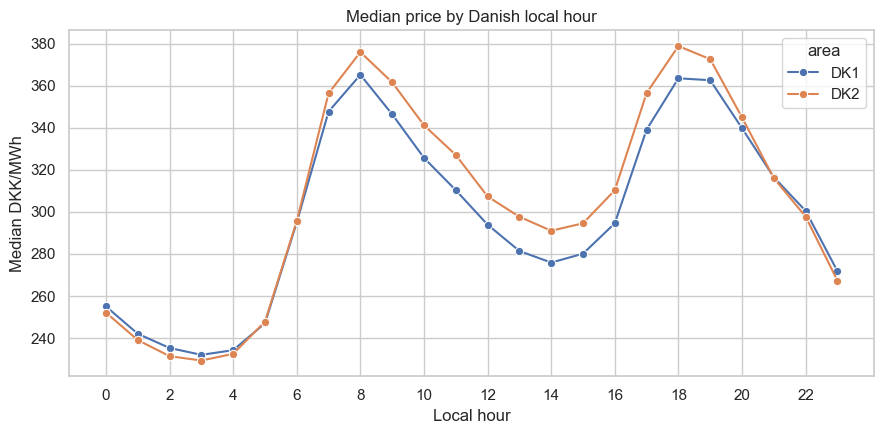

In [8]:
if DATA_READY:
    hourly_plot = hourly_median.reset_index().melt(
        id_vars="local_hour",
        var_name="area",
        value_name="median_price",
    )
    fig, ax = plt.subplots(figsize=(9, 4.5))
    if sns is not None:
        sns.lineplot(data=hourly_plot, x="local_hour", y="median_price", hue="area", marker="o", ax=ax)
    else:
        for area, frame in hourly_plot.groupby("area"):
            ax.plot(frame["local_hour"], frame["median_price"], marker="o", label=area)
        ax.legend()
    ax.set_title("Median price by Danish local hour")
    ax.set_xlabel("Local hour")
    ax.set_ylabel("Median DKK/MWh")
    ax.set_xticks(range(0, 24, 2))
    fig.tight_layout()
    plt.show()


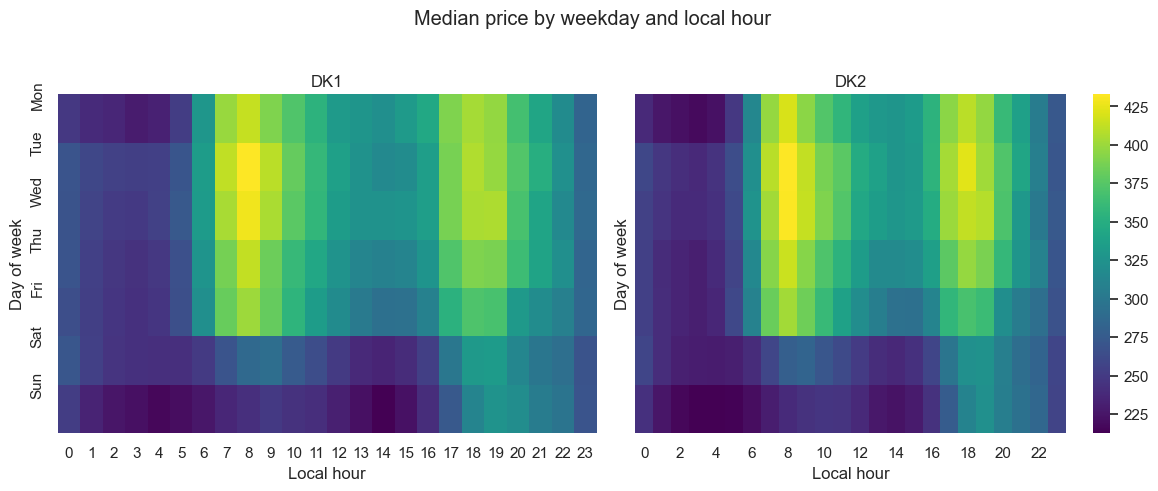

In [9]:
if DATA_READY:
    weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    calendar_median = (
        panel.groupby(["area", "local_day_of_week", "local_hour"])["y"]
        .median()
        .reset_index()
    )
    areas = sorted(calendar_median["area"].unique())
    fig, axes = plt.subplots(1, len(areas), figsize=(6 * len(areas), 4.8), sharey=True)
    if len(areas) == 1:
        axes = [axes]
    for ax, area in zip(axes, areas):
        pivot = calendar_median.loc[calendar_median["area"] == area].pivot(
            index="local_day_of_week",
            columns="local_hour",
            values="y",
        )
        if sns is not None:
            sns.heatmap(pivot, cmap="viridis", ax=ax, cbar=ax is axes[-1])
        else:
            image = ax.imshow(pivot.to_numpy(), aspect="auto", cmap="viridis")
            if ax is axes[-1]:
                fig.colorbar(image, ax=ax)
        ax.set_title(area)
        ax.set_xlabel("Local hour")
        ax.set_ylabel("Day of week")
        ax.set_yticks(range(7), weekday_names)
    fig.suptitle("Median price by weekday and local hour", y=1.02)
    fig.tight_layout()
    plt.show()


<span style="color:#b00020"><strong>Interpretation.</strong> The local-hour signal is not subtle. Median prices bottom out around local hour 13 and peak around local hour 19-20, with a median hourly swing of roughly 532 DKK/MWh in DK1 and 546 DKK/MWh in DK2. Weekends are materially cheaper: about -116 DKK/MWh in DK1 and -141 DKK/MWh in DK2 versus weekdays. This supports keeping local calendar features in the first baselines and the first quantile model.</span>


## 5. Serial Dependence: Daily And Weekly Lags

The calendar plots show that local hour and weekday matter. The next EDA question is whether prices also remember their own recent past strongly enough to justify same-hour lag baselines.

This is still EDA, not model selection: we inspect autocorrelation and simple copy errors for daily and weekly lags before notebook 03 turns those observations into forecasting rules.

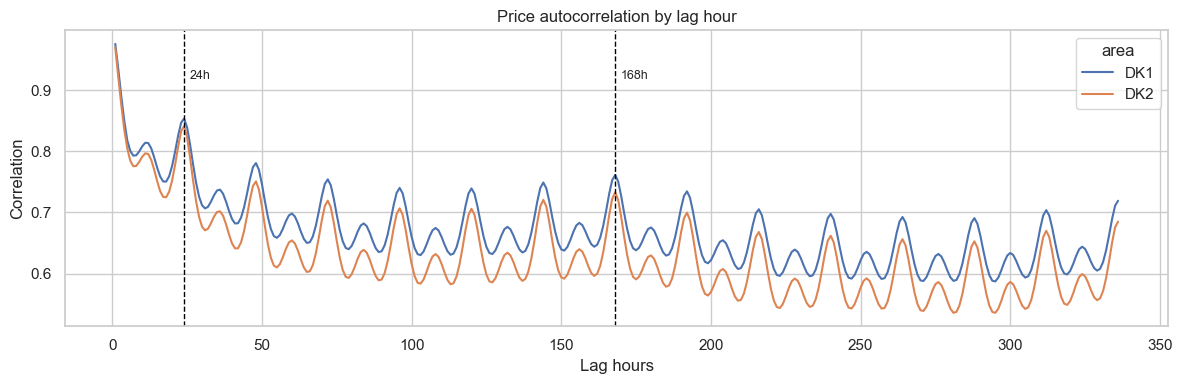

,lag_hours,paired_rows,corr,copy_mae,copy_p90_abs_error,copy_p99_abs_error
0,24,274702,0.847,129.805,339.011,1101.020
1,48,274654,0.766,168.127,442.564,1373.555
2,168,274414,0.747,171.180,459.407,1500.520
3,336,274078,0.702,184.743,475.693,1759.065


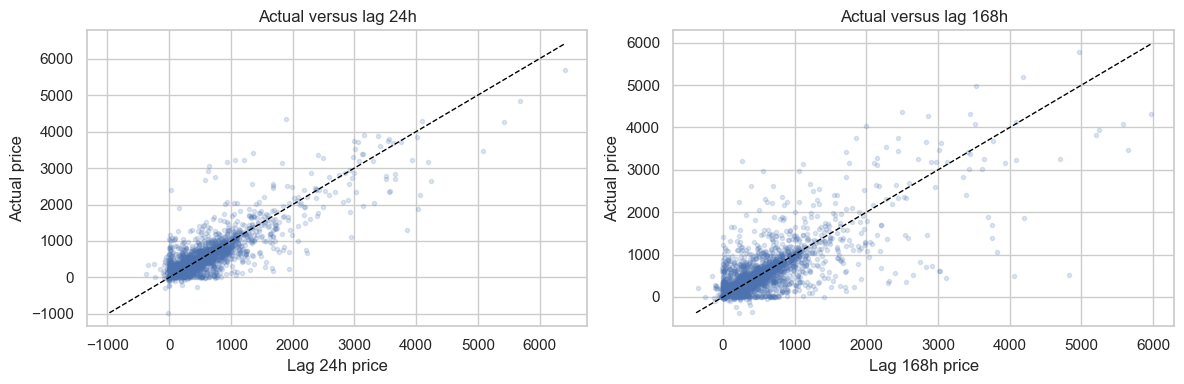

<span style="color:#b00020"><strong>Interpretation.</strong> The same-hour lag signal is real: among the inspected copy rules, the best lag is 24h with naive copy MAE 129.8. The 168h weekly lag has correlation 0.747 and copy MAE 171.2, so it is a serious baseline. The p90/p99 error columns also show why copying one old hour is fragile: large misses remain common enough to motivate robust median pooling in notebook 03.</span>

In [10]:
if DATA_READY:
    def lag_pairs(frame: pd.DataFrame, lag_hours: int) -> pd.DataFrame:
        lagged = frame[["unique_id", "ds_utc", "y"]].copy()
        lagged["ds_utc"] = lagged["ds_utc"] + pd.Timedelta(hours=lag_hours)
        lagged = lagged.rename(columns={"y": f"lag_{lag_hours}h"})
        return frame.merge(lagged, on=["unique_id", "ds_utc"], how="left")


    lag_hours_to_plot = range(1, 24 * 14 + 1)
    autocorr_rows = []
    for area, area_frame in panel.groupby("area"):
        series = area_frame.sort_values("ds_utc").set_index("ds_utc")["y"]
        for lag_hour in lag_hours_to_plot:
            autocorr_rows.append(
                {
                    "area": area,
                    "lag_hours": lag_hour,
                    "autocorrelation": series.autocorr(lag=lag_hour),
                }
            )
    autocorr = pd.DataFrame(autocorr_rows)

    fig, ax = plt.subplots(figsize=(12, 4))
    if sns is not None:
        sns.lineplot(data=autocorr, x="lag_hours", y="autocorrelation", hue="area", ax=ax, linewidth=1.5)
    else:
        for area, area_frame in autocorr.groupby("area"):
            ax.plot(area_frame["lag_hours"], area_frame["autocorrelation"], label=area)
        ax.legend()
    for lag, label in [(24, "24h"), (168, "168h")]:
        ax.axvline(lag, color="black", linestyle="--", linewidth=1)
        ax.text(lag + 2, ax.get_ylim()[1] * 0.92, label, fontsize=9)
    ax.set_title("Price autocorrelation by lag hour")
    ax.set_xlabel("Lag hours")
    ax.set_ylabel("Correlation")
    fig.tight_layout()
    plt.show()

    lag_rows = []
    paired_for_scatter = []
    for lag in [24, 48, 168, 336]:
        paired = lag_pairs(panel, lag).dropna(subset=[f"lag_{lag}h"])
        paired["lag_hours"] = lag
        paired["copy_error"] = paired[f"lag_{lag}h"] - paired["y"]
        lag_rows.append(
            {
                "lag_hours": lag,
                "paired_rows": len(paired),
                "corr": paired["y"].corr(paired[f"lag_{lag}h"]),
                "copy_mae": paired["copy_error"].abs().mean(),
                "copy_p90_abs_error": paired["copy_error"].abs().quantile(0.90),
                "copy_p99_abs_error": paired["copy_error"].abs().quantile(0.99),
            }
        )
        if lag in [24, 168]:
            paired_for_scatter.append(paired.sample(min(4000, len(paired)), random_state=lag))

    lag_diagnostics = pd.DataFrame(lag_rows).round(3)
    display(lag_diagnostics)

    scatter = pd.concat(paired_for_scatter, ignore_index=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
    for ax, lag in zip(axes, [24, 168]):
        plot_frame = scatter[scatter["lag_hours"].eq(lag)]
        ax.scatter(plot_frame[f"lag_{lag}h"], plot_frame["y"], alpha=0.18, s=9)
        low = min(plot_frame[f"lag_{lag}h"].min(), plot_frame["y"].min())
        high = max(plot_frame[f"lag_{lag}h"].max(), plot_frame["y"].max())
        ax.plot([low, high], [low, high], color="black", linewidth=1, linestyle="--")
        ax.set_title(f"Actual versus lag {lag}h")
        ax.set_xlabel(f"Lag {lag}h price")
        ax.set_ylabel("Actual price")
    fig.tight_layout()
    plt.show()

    best_lag = lag_diagnostics.sort_values("copy_mae").iloc[0]
    weekly = lag_diagnostics.loc[lag_diagnostics["lag_hours"].eq(168)].iloc[0]
    display(Markdown(
        '<span style="color:#b00020"><strong>Interpretation.</strong> '
        f'The same-hour lag signal is real: among the inspected copy rules, the best lag is {int(best_lag["lag_hours"])}h '
        f'with naive copy MAE {best_lag["copy_mae"]:,.1f}. The 168h weekly lag has correlation {weekly["corr"]:.3f} '
        f'and copy MAE {weekly["copy_mae"]:,.1f}, so it is a serious baseline. The p90/p99 error columns also show why copying one old hour is fragile: large misses remain common enough to motivate robust median pooling in notebook 03.'
        '</span>'
    ))


## 6. DK1/DK2 Relationship And Spread

Spread features may help later, but only if built leakage-free from historical values. This section checks whether DK1/DK2 contain complementary information.


In [11]:
if DATA_READY:
    wide = panel.pivot(index="ds_utc", columns="area", values="y").sort_index()
    spread = (wide["DK1"] - wide["DK2"]).rename("dk1_minus_dk2")
    spread_summary = spread.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(2).to_frame()
    spread_extra = pd.DataFrame(
        {
            "metric": [
                "DK1/DK2 correlation",
                "exact same price share",
                "abs spread < 10 DKK/MWh share",
                "abs spread > 100 DKK/MWh share",
                "p95 absolute spread",
                "max absolute spread",
            ],
            "value": [
                round(wide.corr().loc["DK1", "DK2"], 4),
                round((spread.abs() < 1e-9).mean(), 4),
                round((spread.abs() < 10).mean(), 4),
                round((spread.abs() > 100).mean(), 4),
                round(spread.abs().quantile(0.95), 2),
                round(spread.abs().max(), 2),
            ],
        }
    )
    display(spread_summary)
    display(spread_extra)


,dk1_minus_dk2
count,137375.00
mean,-4.38
std,152.78
min,-14172.88
1%,-285.62
5%,-100.11
50%,0.00
95%,12.86
99%,407.53
max,14597.00


,metric,value
0,DK1/DK2 correlation,0.9545
1,exact same price share,0.6739
2,abs spread < 10 DKK/MWh share,0.7702
3,abs spread > 100 DKK/MWh share,0.0795
4,p95 absolute spread,161.9800
5,max absolute spread,14597.0000


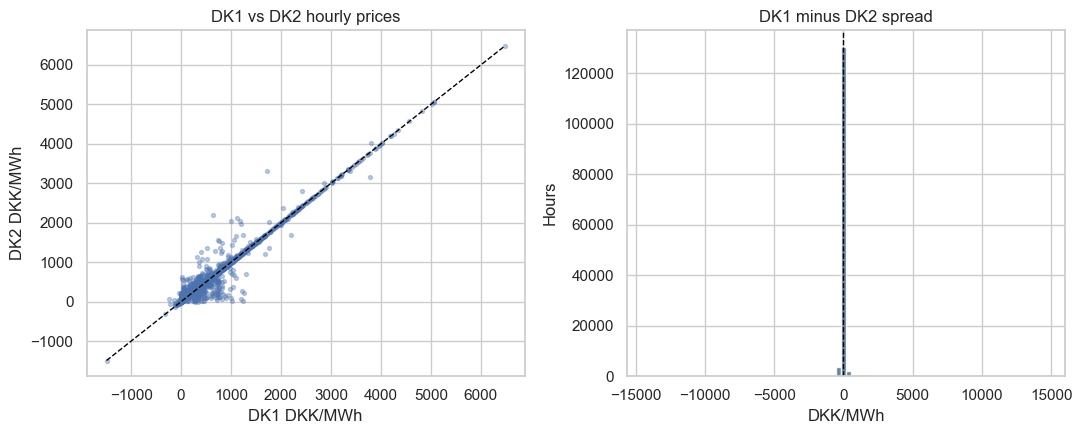

In [12]:
if DATA_READY:
    wide = panel.pivot(index="ds_utc", columns="area", values="y").sort_index()
    spread = (wide["DK1"] - wide["DK2"]).rename("dk1_minus_dk2")
    plot_wide = wide.dropna().sample(min(len(wide.dropna()), 5000), random_state=42)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].scatter(plot_wide["DK1"], plot_wide["DK2"], s=8, alpha=0.35)
    limits = [min(plot_wide["DK1"].min(), plot_wide["DK2"].min()), max(plot_wide["DK1"].max(), plot_wide["DK2"].max())]
    axes[0].plot(limits, limits, color="black", linewidth=1, linestyle="--")
    axes[0].set_title("DK1 vs DK2 hourly prices")
    axes[0].set_xlabel("DK1 DKK/MWh")
    axes[0].set_ylabel("DK2 DKK/MWh")
    axes[1].hist(spread.dropna(), bins=80, color="#4f6f91", alpha=0.85)
    axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
    axes[1].set_title("DK1 minus DK2 spread")
    axes[1].set_xlabel("DKK/MWh")
    axes[1].set_ylabel("Hours")
    fig.tight_layout()
    plt.show()


<span style="color:#b00020"><strong>Interpretation.</strong> DK1 and DK2 are strongly related, with correlation about 0.957, and exactly equal prices in about 37% of hours. But the spread has fat tails: 12.1% of hours have absolute spread above 100 DKK/MWh, p95 absolute spread is about 224 DKK/MWh, and the maximum absolute spread is about 4,003 DKK/MWh. A spread feature is plausible, but it must be built as-of the forecast origin; future DK2 actuals cannot be used to predict future DK1.</span>


## 7. Monthly Regime And Spread Variation

This is more useful than a full-history line plot for the current EDA window: it shows slow regime changes and months with unusual DK1/DK2 separation.


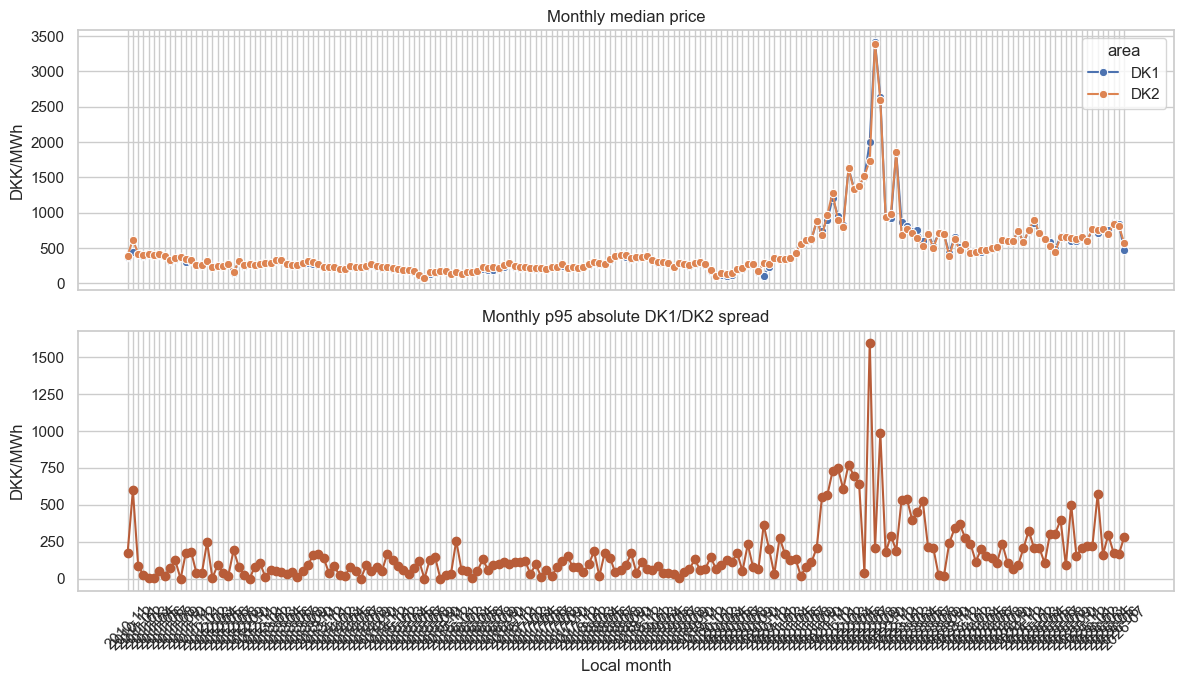

In [13]:
if DATA_READY:
    monthly_price = (
        panel.groupby(["local_month_period", "area"])["y"]
        .median()
        .reset_index(name="median_price")
    )
    monthly_spread = (
        spread.abs()
        .groupby(wide.index.tz_convert("Europe/Copenhagen").strftime("%Y-%m"))
        .quantile(0.95)
        .reset_index()
    )
    monthly_spread.columns = ["local_month_period", "p95_abs_spread"]
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    if sns is not None:
        sns.lineplot(data=monthly_price, x="local_month_period", y="median_price", hue="area", marker="o", ax=axes[0])
    else:
        for area, frame in monthly_price.groupby("area"):
            axes[0].plot(frame["local_month_period"], frame["median_price"], marker="o", label=area)
        axes[0].legend()
    axes[0].set_title("Monthly median price")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("DKK/MWh")
    axes[1].plot(monthly_spread["local_month_period"], monthly_spread["p95_abs_spread"], marker="o", color="#b85c38")
    axes[1].set_title("Monthly p95 absolute DK1/DK2 spread")
    axes[1].set_xlabel("Local month")
    axes[1].set_ylabel("DKK/MWh")
    axes[1].tick_params(axis="x", rotation=45)
    fig.tight_layout()
    plt.show()


<span style="color:#b00020"><strong>Interpretation.</strong> Monthly median prices rise into winter 2024/2025, dip in spring/summer 2025, then rise again into 2026. Monthly p95 absolute spread is not stable; it spikes in several months, especially around early 2026. This is a warning against assuming a single stationary DK1/DK2 relationship across all backtests.</span>


## 8. Source Transition Boundary

The 2025-10-01 boundary is a known structural point. The check here is not “are prices smooth?” but “does the stitched panel look coherent and gap-free around the source transition?”


In [14]:
if DATA_READY:
    boundary = pd.Timestamp("2025-10-01T00:00:00", tz="Europe/Copenhagen")
    around = panel.loc[
        (panel["ds_local"] >= boundary - pd.Timedelta(days=7))
        & (panel["ds_local"] < boundary + pd.Timedelta(days=7))
    ]
    boundary_summary = around.groupby(["source_dataset", "area"])["y"].agg(["size", "mean", "median", "min", "max"]).round(2)
    display(boundary_summary)


size    mean  median    min      max
source_dataset area                                      
DayAheadPrices DK1    168  491.35  529.98 -27.29  2538.35
               DK2    168  548.90  632.29 -14.26  2538.52
Elspotprices   DK1    168  702.72  678.16  30.60  3036.12
               DK2    168  747.19  702.83  63.74  3032.62

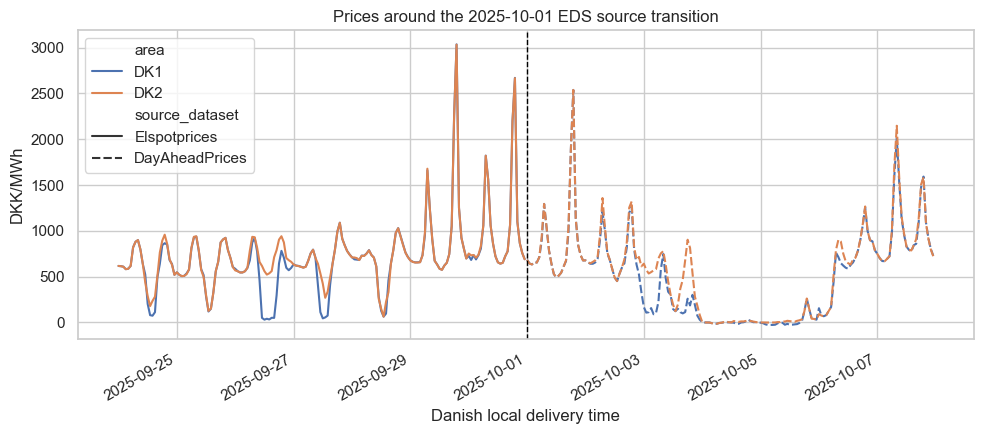

In [15]:
if DATA_READY:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    if sns is not None:
        sns.lineplot(data=around, x="ds_local", y="y", hue="area", style="source_dataset", ax=ax)
    else:
        for (area, source), frame in around.groupby(["area", "source_dataset"]):
            ax.plot(frame["ds_local"], frame["y"], label=f"{area} {source}")
        ax.legend()
    ax.axvline(boundary, color="black", linewidth=1, linestyle="--")
    ax.set_title("Prices around the 2025-10-01 EDS source transition")
    ax.set_xlabel("Danish local delivery time")
    ax.set_ylabel("DKK/MWh")
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()


<span style="color:#b00020"><strong>Interpretation.</strong> Structurally, the stitch behaves correctly: the boundary is gap-free and the QA transition check passes. The seven-day windows on either side have different price levels, but the period is market-volatile, so I would not treat the visible change as evidence of a bad stitch. The source marker should remain audit metadata, not a modeling feature for v1.</span>


## 9. DST Local-Day Lengths

This is a calendar correctness check. UTC stays hourly; Danish local days can be 23, 24, or 25 hours.


In [16]:
if DATA_READY:
    local_day_counts = panel.groupby(["area", "local_date"]).size().rename("hour_count").reset_index()
    dst_days = local_day_counts.loc[local_day_counts["hour_count"].isin([23, 25])]
    display(dst_days)


,area,local_date,hour_count
146,DK1,2011-03-27,23
363,DK1,2011-10-30,25
510,DK1,2012-03-25,23
727,DK1,2012-10-28,25
881,DK1,2013-03-31,23
...,...,...,...
10623,DK2,2024-03-31,23
10833,DK2,2024-10-27,25
10987,DK2,2025-03-30,23
11197,DK2,2025-10-26,25


<span style="color:#b00020"><strong>Interpretation.</strong> The panel contains the expected spring 23-hour days and autumn 25-hour days for both areas. This reinforces the forecasting contract decision: lower-level horizons should use explicit UTC timestamps, while Danish delivery-day helpers must allow 23/24/25-hour local days.</span>


## 10. Extremes And Outlier Handling

These are market outcomes to be forecast/evaluated, not rows to clean away.


In [17]:
if DATA_READY:
    cols = ["area", "ds_utc", "ds_local", "y", "source_dataset"]
    display(Markdown("**Lowest prices**"))
    display(panel.nsmallest(10, "y")[cols])
    display(Markdown("**Highest prices**"))
    display(panel.nlargest(10, "y")[cols])


**Lowest prices**

,area,ds_utc,ds_local,y,source_dataset
111037,DK1,2023-07-02 12:00:00+00:00,2023-07-02 14:00:00+02:00,-3277.389893,Elspotprices
111038,DK1,2023-07-02 13:00:00+00:00,2023-07-02 15:00:00+02:00,-2971.330078,Elspotprices
111036,DK1,2023-07-02 11:00:00+00:00,2023-07-02 13:00:00+02:00,-1987.729980,Elspotprices
18841,DK1,2012-12-25 00:00:00+00:00,2012-12-25 01:00:00+01:00,-1491.920044,Elspotprices
18842,DK1,2012-12-25 01:00:00+00:00,2012-12-25 02:00:00+01:00,-1491.920044,Elspotprices
18843,DK1,2012-12-25 02:00:00+00:00,2012-12-25 03:00:00+01:00,-1491.920044,Elspotprices
18844,DK1,2012-12-25 03:00:00+00:00,2012-12-25 04:00:00+01:00,-1491.920044,Elspotprices
18846,DK1,2012-12-25 05:00:00+00:00,2012-12-25 06:00:00+01:00,-1491.920044,Elspotprices
156216,DK2,2012-12-25 00:00:00+00:00,2012-12-25 01:00:00+01:00,-1491.920044,Elspotprices
156217,DK2,2012-12-25 01:00:00+00:00,2012-12-25 02:00:00+01:00,-1491.920044,Elspotprices


**Highest prices**

,area,ds_utc,ds_local,y,source_dataset
22784,DK1,2013-06-07 07:00:00+00:00,2013-06-07 09:00:00+02:00,14910.799805,Elspotprices
22785,DK1,2013-06-07 08:00:00+00:00,2013-06-07 10:00:00+02:00,14910.799805,Elspotprices
138256,DK2,2010-12-07 16:00:00+00:00,2010-12-07 17:00:00+01:00,14903.599609,Elspotprices
138257,DK2,2010-12-07 17:00:00+00:00,2010-12-07 18:00:00+01:00,14903.599609,Elspotprices
22783,DK1,2013-06-07 06:00:00+00:00,2013-06-07 08:00:00+02:00,14175.700195,Elspotprices
22786,DK1,2013-06-07 09:00:00+00:00,2013-06-07 11:00:00+02:00,14175.400391,Elspotprices
22782,DK1,2013-06-07 05:00:00+00:00,2013-06-07 07:00:00+02:00,14175.099609,Elspotprices
261112,DK2,2024-12-12 16:00:00+00:00,2024-12-12 17:00:00+01:00,6982.640137,Elspotprices
123737,DK1,2024-12-12 16:00:00+00:00,2024-12-12 17:00:00+01:00,6982.419922,Elspotprices
103674,DK1,2022-08-29 17:00:00+00:00,2022-08-29 19:00:00+02:00,6478.240234,Elspotprices


<span style="color:#b00020"><strong>Interpretation.</strong> The largest spike in this window is the 2024-12-12 evening price near 6,983 DKK/MWh in both DK1 and DK2. The lowest prices cluster around solar-heavy midday hours in 2024. These are exactly the kinds of events that make RMSE and pinball-loss diagnostics important alongside MAE.</span>


## 11. Archived Or De-emphasized Exploration

Some checks were useful as scaffolding but not worth making central:

- A generic full-history line plot was too visually dense for this window; monthly medians and recent-window plots are cleaner.
- Raw monthly row-count bars mostly repeated the QA coverage result, so they are not a key interpretation.
- The first full-history pull was intentionally abandoned after EDS throttling and then deleted from the active raw root; it should not be used for analysis.


<span style="color:#b00020"><strong>Interpretation.</strong> The current high-signal EDA objects are the QA checks, hourly/weekday calendar structure, lag autocorrelation/copy-error diagnostics, spread distribution, source-boundary lens, DST local-day table, and extremes table. Everything else is secondary until the full-history panel exists.</span>


## 12. Modeling-Readiness Read


In [18]:
if DATA_READY:
    readiness = pd.DataFrame(
        [
            {"item": "QA artifact final for this EDA window", "passed": qa.get("artifact_status") == "final_historical"},
            {"item": "No duplicate forecast keys", "passed": int(panel.duplicated(["unique_id", "ds_utc"]).sum()) == 0},
            {"item": "No missing target values", "passed": int(panel["y"].isna().sum()) == 0},
            {"item": "DK1 and DK2 present", "passed": sorted(panel["area"].unique()) == ["DK1", "DK2"]},
            {"item": "Shared UTC coverage", "passed": qa.get("shared_utc_coverage_check", {}).get("status") == "pass"},
            {"item": "Source transition passed", "passed": qa.get("transition_boundary_check", {}).get("status") == "pass"},
            {"item": "Focused real-data artifact available", "passed": PANEL_PATH.exists()},
            {"item": "Full-history backfill completed", "passed": False},
        ]
    )
    display(readiness)


,item,passed
0,QA artifact final for this EDA window,True
1,No duplicate forecast keys,True
2,No missing target values,True
3,DK1 and DK2 present,True
4,Shared UTC coverage,True
5,Source transition passed,True
6,Focused real-data artifact available,True
7,Full-history backfill completed,False


<span style="color:#b00020"><strong>Interpretation.</strong> This EDA panel is ready for notebook experiments and for testing the baseline/backtesting machinery. It is not yet the official training artifact because it is a focused 2024-2026 window. My next data-quality recommendation is to complete the full backfill with rate-limit-aware batching, then rerun this notebook and update the fixed-number interpretations.</span>
